In [44]:
# 在拔电源重新上电后需要执行以下三行，等待设备重启
# from nsqdriver import MCIDriver, QSYNCDriver
# driverUpdate = MCIDriver("192.168.1.217", 120)
# driverUpdate.open(debug=True)
# addr = r"D:\Microsoft Download\AA375110BOOT (7).BIN"
# addr = r"D:\Microsoft Download\AA39.BIN"

# addr = r"D:\Microsoft Download\POWERQ_AWG_RD_BOOT_AA335416 (6).bin"
# driverUpdate.update_firmware(addr, [9], 2)


In [884]:
# # 在拔电源重新上电后需要执行以下三行，等待设备重启
from nsqdriver import MCIDriver, QSYNCDriver
driverUpdate = MCIDriver("192.168.1.217", 120)
driverUpdate.open(debug=True)
driverUpdate.set("FirmwareChange", [1,1,1, 2], ["S3-O1","S5-O1","S7-O1", "S9-O1"]) 
#driverUpdate.set("FirmwareChange", [1,1,1, 2], ["S3-O1","S5-O1","S7-O1" "S9-O1"]) 
#driverUpdate.set("FirmwareChange", [1], ["S5-O1"]) 
# 对于S9 1 :指令集固件： 0 ：awg 固件 ： 2 指令集固件（float32）
# 对于S， 0： awg固件， 1：指令集固件
# example：切回awg driverUpdate.set("FirmwareChange", [0, 0], ["S5-O1", "S9-O1"]) 

# init and define

In [1]:
import numpy as np
import qcodes as qc

## Multidimensional scanning module
from qcodes.dataset import (
    LinSweep,
    Measurement,
    dond,
    experiments,
    initialise_or_create_database_at,
    load_by_run_spec,
    load_or_create_experiment,
    plot_dataset,
)
## Dummy instruments for generating synthetic data
from qcodes.instrument_drivers.mock_instruments import (
    DummyInstrument,
    DummyInstrumentWithMeasurement,
)
## Using interactive widget
from qcodes.interactive_widget import experiments_widget

In [40]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
import nsqdriver.nswave as nw
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import time
# 第2部分
SHARED_DEVICE_MEM.clear_ip()

#input("关闭放大器后再按回车！！！！")
#time.sleep(10)
try:
    qsync.set("ResetTrig")
except Exception as e:
    pass

try:
    for i in range(4):
        device.set("Output", 0, f"S9-O{i+1}")
except Exception as e:
    pass

# 第3部分
deviceIP = "192.168.1.217"
qsync_ip = "192.168.1.217"
device = MCIDriver(deviceIP, 40)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate = 8e9
ADrate = 4e9

DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
sysparam = {
    "MixMode": 2,  # 0~fs/2写1， fs/2~fs写2
    "RefClock": "out",
    "DArate_S5-O1": DArate,
    "DArate_S3-O1": DArate,
    "DArate_S7-O1": DArate,
    "ADrate": ADrate,
    "CaptureMode": 0,
    "INMixMode": 2,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in","TrigWidth": 25e-6} # 设置TrigWidth等于period的1/4
cycle = round((ADrate * 1e-9) * (DArate * 1e-9) * 0.125)
# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()
#time.sleep(10)

#print("打开放大器!!!!!")

# 设置接地
slot = 9
for i in range(4):
    port_name= f'S{slot}-O{int(i+1)}'
    device.set('CustomALite', [0x01F0_0000+16*4, 0x0], port_name) 

*********QSYNC192.168.1.217开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.1.217 opened successfully
*********设备192.168.1.217开启成功*********
device_type: pqtm
backend_version: v2.11.5-8-g2e831e8
ad_num: 4
da_num: 20
cpu_temp: 68.0
memory_use: 16.3
available chnl: 
OUT Chnl: ['S5-O1', 'S5-O2', 'S5-O3', 'S5-O4', 'S5-O5', 'S5-O6', 'S5-O7', 'S5-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.1.217开启成功
System synchronization succeeded


In [3]:
import logging
# qcodes imports
from qcodes.dataset import (
    Measurement,
    load_experiment_by_name,
    new_experiment,
    plot_by_id,
)
from qcodes.instrument_drivers.Keysight import KeysightN5245A

# setup
logger = logging.getLogger()
logger.setLevel(logging.DEBUG)
from qcodes.dataset.sqlite.database import initialise_or_create_database_at
#Select one path to save data db file
import os
db_filename='251010.db'
db_file_path=os.path.join('D:\\Test_data\\naishu',db_filename)
initialise_or_create_database_at(db_file_path)
# Start experiment
exp_name = "Test"
sample_name = "Thru_Coax"
try:
    exp = load_experiment_by_name(exp_name, sample=sample_name)
    print("Experiment loaded. Last ID no:", exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print("Starting new experiment.")

Experiment loaded. Last ID no: 0


In [4]:
import qcodes as qc
from qcodes.instrument_drivers.SIMIT.DataLogger1 import DataLogger

In [5]:
import qcodes as qc
from qcodes.instrument_drivers.SIMIT.DataLogger1 import DataLogger

In [6]:
station = qc.Station()

In [7]:
DL1=DataLogger("DL1")
station.add_component(DL1)

'DL1'

In [8]:
DL2=DataLogger("DL2")
station.add_component(DL2)

'DL2'

In [9]:
DL3=DataLogger("DL3")
station.add_component(DL3)

'DL3'

In [10]:
DL4=DataLogger("DL4")
station.add_component(DL4)

'DL4'

## Multigate_Sequence

In [11]:
def Multigate_sequence_new(ch, waveform_bank,delay,spacing_time=24e-9):
    # 用于多个波形的播放
    i=ch-1
    shape_list=waveform_bank[0]
    center_list=waveform_bank[4]
    pw_list=waveform_bank[1]
    ew_list=waveform_bank[2]
    freq_list=waveform_bank[6] 
    
    phase_list=waveform_bank[5]
    amp_list=waveform_bank[3]
    
    shape = shape_list[0]
    pw = pw_list[0]
    ew = ew_list[0]
    xyfreq = freq_list[0]
    fs = DArate_xy
    freq = round(xyfreq * (2**32) / fs)
    cycle = round((ADrate * 1e-9) * (DArate * 1e-9) * 0.125)
    pw_list_new = [round(cycle*np.ceil(round((pw_one)*1e9*10)/10/cycle))*1e-9 for pw_one in pw_list]
    sequence_length = sum(pw_list_new) + 2*sum(ew_list) + (len(shape_list)-1)*spacing_time
    delay = delay-sequence_length
    wait_cycle0 = round(delay * 1e9 / cycle)
    pw_dict = {}
    for pw_one in pw_list:
        pw_one_mod = str(round(pw_one*DArate % (DArate*1e-9*cycle)))
        if (pw_one_mod not in pw_dict) or (pw_one > pw_dict[pw_one_mod]):
            pw_dict[pw_one_mod]=pw_one
    envelope = np.array([])
    start_slice_dict = {}
    for key in pw_dict:
        pw=pw_dict[key]
        if shape=='Square':
            w=round(pw*DArate_xy)
            pw_cycle = round(np.ceil(round((pw)*1e9*10)/10/cycle))
            if pw_cycle < 8:
                pw_cycle = 8
            e = round((pw_cycle*cycle*1e-9-pw)*DArate_xy)
            if e:
                env = np.concatenate((np.zeros(e),np.ones(w)))
            else:
                env = np.ones(w)
        start_slice = round(len(envelope)//32)
        start_slice_dict[key] = start_slice

        envelope = np.concatenate((envelope, env))  # 生成包络
    wave = envelope
    wave = np.hstack(1 * (wave,))
    qsync.set("ResetTrig")
    device.set("Output", 1, f"S5-O{ch}")  # 将包络下发给8个通道
    device.set("Envelope", wave, (f"S5-O{ch}"))
    phi = 0
    phi_cont = 0
    program = f"""
    nop
    fmsi 0b1 {freq} {phi} # 设置frame1, 的频率为 4.1G,相位为90°
    nop
    nop
    nop
    nop
    nop
    wtg
    nop
    nop
    nop
    nop
    nop
    witi {wait_cycle0}
    """

    for i in range(len(phase_list)):
        phi = phase_list[i]%360
        #phi = (phi+phi_cont)%360
        phi = round(phi * (2**16) / 360 / 32)  # 计算载波90°相位对应的参数值
        cycle = round((ADrate * 1e-9) * (DArate_xy * 1e-9) * 0.125)  # cycle的计算公式
        pw = pw_list[i]
        play_cycle = round(np.ceil(round((pw)*1e9*10)/10/ cycle)) # 时间单位换算成cycle
        if play_cycle < 8:
            play_cycle = 8
        #assert spacing_time >= 24e-9
        spacing_cycle = np.ceil(round((spacing_time)*1e9*10)/10/ cycle)  # 时间单位换算成cycle
        wait_cycle = round(play_cycle + spacing_cycle - 2 - 2 - 3)
        # 等待时间为想要播放的时间-上一条指令的cycle - 自身指令的cycle - 后面必须跟的3个nop指令的cycle - 重置相位必要指令的cycle
        ## 编写指令
        amp_dig=round(amp_list[i]*32767)
        pw_now_mod = str(round(pw*DArate % (DArate*1e-9*cycle)))
        start_slice = start_slice_dict[pw_now_mod]
        program += f"""nop
    nop
    nop
    plyi 0 {start_slice} {play_cycle} {amp_dig} 0 0 {phi} 
    # 0 代表选择第一个frame 包络从第0点开始播放, 播放时长6us, 幅值设为最大值32767, 另外3个参数预留设置为0
    witi {wait_cycle} # 等待播放完成
    """
        #phi_cont += (360 * xyfreq * (wait_cycle + 13) * 4e-9 ) % 360
    program += f"""nop
    nop
    nop
    jali $0 # 执行到此后台跳转到第0条指令,等待触发
    nop
    nop
    nop
    """

    device.set("Assemble", program, f"S5-O{ch}")
    qsync.set("Shot", 0xFFFFFFFF)
    #qsync.set("GenerateTrig", period)   #若需要持续播放该序列，取消注释该行

## S21_measure

In [18]:
import nsqdriver.nswave as nw
@nw.kernel
def program_rd(delay: nw.Var, in_delay: nw.Var, sample_length: nw.Var):
    nw.wait_for_trigger()
    
    nw.wait(delay+in_delay+4.096e-6-sample_length)
    #nw.wait(delay+in_delay)#
    nw.capture(sample_length,0,0)
    
    
    return nw.Kernel()
#device.set('ProgramIN', program_rd(delay=10e-6,in_delay=0e-9,sample_length=2.48e-9), f'S{slot}-I{1}')

@nw.kernel
def program_xy_onepulse(freq: nw.Var, amp: nw.Var, width: nw.Var, delay: nw.Var):
    srate: nw.Var = 8e9
    #width: nw.Var =4.096e-6
    time_line: np.ndarray = np.linspace(0, width, int(width * srate),endpoint=False)
    wave: np.ndarray = amp*np.cos(2 * np.pi * time_line * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.reset_frame()   
    nw.wait(delay)
    nw.play_wave(envelope_0, 1, 0, 0) #envelope \ amp \ ext_freq \ ext_phase
    return nw.Kernel()
#device.set('ProgramOUT',program_xy_onepulse(1e9,0.9,4.096e-6,0e-6),  f'S5-O5')

# def s21measure1freq(I_ch:int,O_ch:int,freq,wave_amp,delay,in_delay,sample_length,period=200e-6): 
#     device.set('ProgramIN', program_rd(delay=delay,in_delay=in_delay,sample_length=sample_length), f'S9-I{I_ch}')
#     #device.set("TerminateUpload")
#     device.set('PointNumber',4*4096,  f'S9-I{I_ch}')
#     device.set('FreqList', [freq], f'S9-I{I_ch}')
#     device.set('ProgramOUT',program_xy_onepulse(freq=freq, amp=wave_amp, width=4.096e-6, delay=delay),  f'S9-O{O_ch}')
#     shots = 1024*10
#     #shots = 0xFFFFFFFF
#     qsync.set('Shot', shots)
#     device.set('Shot', shots)
#     device.set("TerminateUpload")
#     device.set('StartCapture')
#     time.sleep(0.1)
#     qsync.set('GenerateTrig',period)
#     data = device.get('IQ', f'S9-I{I_ch}',shots)
#     data = np.array(data)
#     data= np.mean(data,axis = 1)
#     return np.abs(data[0])

def s21measure1freq(I_ch:int,O_ch:int,freq,wave_amp,delay,in_delay,sample_length,period=200e-6,shots=1024*10): 
    device.set('ProgramIN', program_rd(delay=delay,in_delay=in_delay,sample_length=sample_length), f'S9-I{I_ch}')
    #device.set("TerminateUpload")
    device.set('PointNumber',4*4096,  f'S9-I{I_ch}')
    device.set('FreqList', [freq]*8, f'S9-I{I_ch}')
    device.set('FreqList', [freq]*8, f'S9-I1')
    device.set('FreqList', [freq]*8, f'S9-I2')
    device.set('FreqList', [freq]*8, f'S9-I3')
    device.set('FreqList', [freq]*8, f'S9-I4')
    device.set('ProgramOUT',program_xy_onepulse(freq=freq, amp=wave_amp, width=4.096e-6, delay=delay),  f'S9-O{O_ch}')
    shots = shots
    #shots = 0xFFFFFFFF
    qsync.set('Shot', shots)
    device.set('Shot', shots)
    device.set("TerminateUpload")
    device.set('StartCapture')
    time.sleep(0.1)
    qsync.set('GenerateTrig',period)
    data = device.get('IQ', f'S9-I{I_ch}',shots)
    data = np.array(data)
    data= np.mean(data,axis = 1)
    return np.abs(data[0])

#def xycontrol_by_nswave(ch,xywidth,xyamp,xyfreq,xyphase,xyelay,period=200e-6):
#device.set("Output", 1, f"S5-O5")
#device.set('ProgramOUT',program_xy_onepulse(1e9,1,1e-6,0e-6),  f'S5-O5')
#s21measure1freq(I_ch=1,O_ch=1,freq=1e9,wave_amp=0.9,delay=1.25e-6,in_delay=in_delay,sample_length=sample_length,period=200e-6)

29896510.0         149.5124053955078
40/41   last spt consume: 2.254181146621704s.
estimate residue time:0.0s


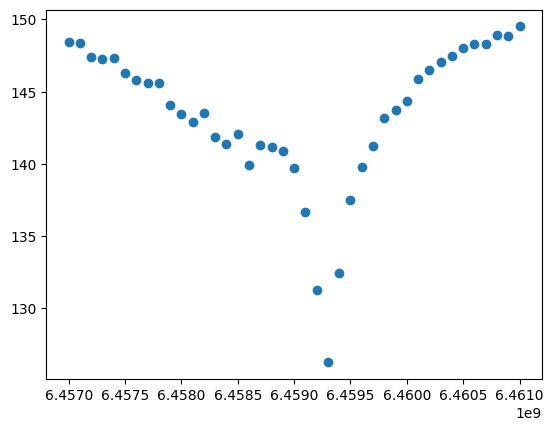

In [33]:
#S21 固定采样时间 xxxxxxxxxxx
exp_name = "Find_fr-C1-6.26393e9-mode2-40dB"
sample_name = "in_delay-sample_length"
try:
    exp = load_experiment_by_name(exp_name, sample=sample_name)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
meas = Measurement(exp=exp,station = station,name="200ns-1524ns-amp1")
meas.register_parameter(DL1.frequency,)
meas.register_parameter(DL1.magnitude,setpoints=(DL1.frequency,))
freq=[]
mag=[]
ix =41


freq_t = 6.459e9#6.258e9  6.26326e9
freq_scan=np.linspace(freq_t-2e6,freq_t+2e6,ix)
in_delay_num = 20
#in_delay = 164e-9
mag = []
freq = []
wave_amp = 0.2
in_delay = 200e-9
sample_length = 4096e-9
with meas.run() as datasaver:
    for n in range(ix):
        #device.set("Reset")
        t2 = time.time()
        resul=s21measure1freq(I_ch=2,O_ch=2,freq=freq_scan[n],wave_amp=wave_amp,delay=100e-6,in_delay=in_delay,sample_length=sample_length,period=200e-6)
        freq.append(freq_scan[n])
        clear_output(wait=True)
        print(resul,"       ",20*np.log10(resul))
        mag.append(resul)
        t3 = time.time()
        datasaver.add_result(   (DL1.frequency, freq_scan[n]),
                                (DL1.magnitude, resul)
        )
        print(f"{n}/{ix}   last spt consume: {t3-t2}s.")
        print(f"estimate residue time:{(ix-n-1)*(t3-t2)}s")
    dataset = datasaver.dataset
plt.figure()
plt.scatter(freq, 20*np.log10(mag))
plt.show()